In [10]:
!pip install -q ultralytics opencv-python-headless matplotlib numpy

In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json

In [7]:
#IMAGE_PATH = "test_image.png"
input_root = "FirstFrame_annotate-1/FirstFrame_annotate-1"
output_folder = "FirstFrame_annotate-1/output_images2"
os.makedirs(output_folder, exist_ok=True)

IMAGE_PATH = os.path.join(input_root, "Nd_O_1654056498.09347371137/frame0.jpg")

In [3]:
valid_extensions = (".jpg", ".jpeg", ".png")

In [4]:
model = YOLO('yolov8l.pt')

In [5]:
COCO_CLASSES = {
0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus',
6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant',
11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat',
16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear',
22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag',
27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard',
32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove',
36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle',
40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon',
45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange',
50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut',
55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed',
60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse',
65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microwave', 69: 'oven',
70: 'toaster', 71: 'sink', 72: 'refrigerator', 73: 'book', 74: 'clock',
75: 'vase', 76: 'scissors', 77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'
}

In [6]:
TARGET_CLASSES = {
'person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck'
}

In [7]:
def class_name(cid):
    return COCO_CLASSES.get(int(cid), str(cid))

In [8]:
img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found at {IMAGE_PATH}")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]
print(f"Loaded image with size: {W}x{H}")

Loaded image with size: 1280x720


lane_count = 3 # change this if your road has more lanes left-to-right
lane_boundaries = [] # list of (x1,x2) for each lane
for i in range(lane_count):
    x1 = int(W * i / lane_count)
    x2 = int(W * (i + 1) / lane_count)
    lane_boundaries.append((x1, x2))

vis = img.copy()
overlay = vis.copy()
alpha = 0.15
colors = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),(0,255,255)]
for idx,(x1,x2) in enumerate(lane_boundaries):
    color = colors[idx % len(colors)]
    cv2.rectangle(overlay, (x1,0), (x2,H), color, -1)
cv2.addWeighted(overlay, alpha, vis, 1-alpha, 0, vis)
plt.figure(figsize=(12,6)); plt.imshow(vis); plt.axis('off'); plt.title('Lane regions (auto)')

results = model.predict(source=IMAGE_PATH, conf=0.35, iou=0.5, device="cpu", save=False, verbose=False)
# results is a list (one result per image). We used single image.
res = results[0]

boxes = res.boxes.xyxy.cpu().numpy() # x1,y1,x2,y2
scores = res.boxes.conf.cpu().numpy()
class_ids = res.boxes.cls.cpu().numpy().astype(int)

print(f"Detections: {len(boxes)}")

filtered = []
for (box, score, cid) in zip(boxes, scores, class_ids):
    name = class_name(cid)
    if name not in TARGET_CLASSES:
        continue
    x1,y1,x2,y2 = box
    w = x2-x1; h = y2-y1
    # basic area filter: skip extremely small boxes
    if w*h < 300: # tune threshold based on image scale
        continue
    filtered.append({'box':box, 'score':float(score), 'class_id':int(cid), 'name':name})

print(f"Filtered detections: {len(filtered)}")

lane_counts = [dict() for _ in lane_boundaries] # list of dicts for each lane
lane_items = [[] for _ in lane_boundaries]

for det in filtered:
    x1,y1,x2,y2 = det['box']
    cx = (x1 + x2) / 2.0
# find which lane the centroid x falls into
    lane_idx = None
    for i,(lx1,lx2) in enumerate(lane_boundaries):
        if cx >= lx1 and cx <= lx2:
            lane_idx = i
            break
        if lane_idx is None:
# if centroid outside integer boundaries, clip to nearest
            if cx < lane_boundaries[0][0]: lane_idx = 0
            else: lane_idx = len(lane_boundaries)-1
        name = det['name']
        lane_counts[lane_idx][name] = lane_counts[lane_idx].get(name, 0) + 1
        lane_items[lane_idx].append(det)

for i,counts in enumerate(lane_counts):
    print(f"Lane {i+1} counts:")
    if len(counts)==0:
        print(" (no detections)")
    else:
        for k,v in counts.items():
            print(f" {k}: {v}")

out = img.copy()
for i,(x1,x2) in enumerate(lane_boundaries):
    x1i = int(x1); x2i = int(x2)
    cv2.rectangle(out, (x1i,0), (x2i,H), (255,255,255), 2)
# lane label with counts
    text = f"Lane {i+1}"
    y = 30 + 20*i
    cv2.putText(out, text, (x1i+10,y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
# show counts
    y2 = y + 20
    counts = lane_counts[i]
    for k,v in counts.items():
        cv2.putText(out, f"{k}:{v}", (x1i+10,y2), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        y2 += 20

for i,det in enumerate(filtered):
    x1,y1,x2,y2 = map(int, det['box'])
    cls = det['name']
    score = det['score']
    cv2.rectangle(out, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(out, f"{cls} {score:.2f}", (x1, max(0,y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

plt.figure(figsize=(12,8)); plt.imshow(out); plt.axis('off'); plt.title('Detections with lane counts')

In [10]:
# === Auto-split image into lanes ===
lane_count = 3  # change this if your road has more lanes
lane_boundaries = []
for i in range(lane_count):
    x1 = int(W * i / lane_count)
    x2 = int(W * (i + 1) / lane_count)
    lane_boundaries.append((x1, x2))

# === Detect objects ===
results = model.predict(source=IMAGE_PATH, conf=0.35, iou=0.5, device="cpu", save=False, verbose=False)
res = results[0]

boxes = res.boxes.xyxy.cpu().numpy()
scores = res.boxes.conf.cpu().numpy()
class_ids = res.boxes.cls.cpu().numpy().astype(int)
print(f"Detections: {len(boxes)}")

Detections: 25


In [12]:
lane_counts = [dict() for _ in lane_boundaries]
for det in filtered:
    x1, y1, x2, y2 = det['box']
    cx = (x1 + x2) / 2.0
    lane_idx = None
    for i, (lx1, lx2) in enumerate(lane_boundaries):
        if lx1 <= cx <= lx2:
            lane_idx = i
            break
    if lane_idx is None:
        lane_idx = 0
    name = det['name']
    lane_counts[lane_idx][name] = lane_counts[lane_idx].get(name, 0) + 1

In [13]:
for i, counts in enumerate(lane_counts):
    print(f"\nLane {i+1} counts:")
    if not counts:
        print("  (no detections)")
    else:
        for k, v in counts.items():
            print(f"  {k}: {v}")



Lane 1 counts:
  (no detections)

Lane 2 counts:
  (no detections)

Lane 3 counts:
  (no detections)


In [15]:
out = img.copy()
text_color = (0, 255, 255)  # Yellow text (readable on dark/bright backgrounds)

for i, (x1, x2) in enumerate(lane_boundaries):
    x1i, x2i = int(x1), int(x2)
    cv2.rectangle(out, (x1i, 0), (x2i, H), (255, 255, 255), 2)

    # Lane header
    y = 30 + 20 * i
    cv2.putText(out, f"Lane {i+1}", (x1i + 10, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, text_color, 2)
     # Vehicle counts below
    y2 = y + 20
    for k, v in lane_counts[i].items():
        cv2.putText(out, f"{k}:{v}", (x1i + 10, y2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, text_color, 2)
        y2 += 20

In [16]:
for det in filtered:
    x1, y1, x2, y2 = map(int, det['box'])
    cls, score = det['name'], det['score']
    cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(out, f"{cls} {score:.2f}",
                (x1, max(0, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# === Save annotated image ===
output_img_path = os.path.join(output_folder, "detected_with_counts.jpg")
cv2.imwrite(output_img_path, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))
print(f"\n✅ Annotated image saved to: {output_img_path}")



✅ Annotated image saved to: FirstFrame_annotate-1/output_images2\detected_with_counts.jpg


✅ Vehicle counts saved to: FirstFrame_annotate-1/output_images2\vehicle_counts.json


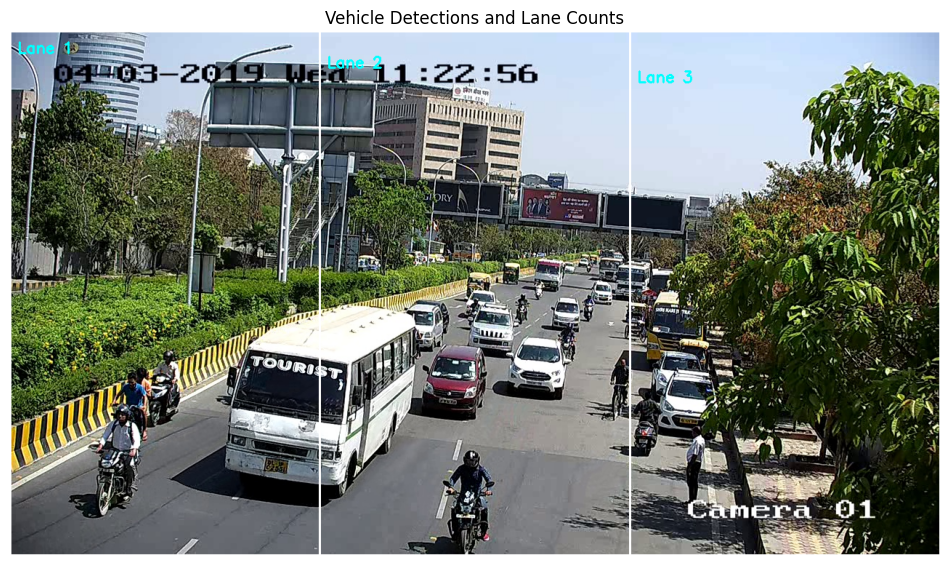

In [17]:
output_json_path = os.path.join(output_folder, "vehicle_counts.json")
lane_data = {f"Lane {i+1}": lane_counts[i] for i in range(len(lane_counts))}

with open(output_json_path, "w") as jf:
    json.dump(lane_data, jf, indent=4)
print(f"✅ Vehicle counts saved to: {output_json_path}")

# === Display final image ===
plt.figure(figsize=(12, 8))
plt.imshow(out)
plt.axis('off')
plt.title('Vehicle Detections and Lane Counts')
plt.show()